# Trabajo Práctico N.º 1

## Diplomatura en Inteligencia Artificial ##  
### Universidad de Palermo ###

- **Año:** 2026
- **Alumno:** Silvio De Cicco
- **Docente:** Martín Jaureguy

---

## Objetivo

- Realizar un análisis exploratorio de datos (EDA) sobre un DataSet de delitos ocurridos en la Ciudad Autónoma de Buenos Aires (CABA) durante el año 2024, con el objetivo de identificar patrones, distribuciones y posibles anomalías presentes en los registros analizados. El DataSet utilizado contiene más de 50.000 registros y 15 variables de tipo categórico, numérico, temporal y geográfico relacionadas con los hechos delictivos registrados.

# Librerias #

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consigna 1: Selección y carga del DataSet #

In [2]:
df = pd.read_csv("delitos_2024.csv")

# Consigna 2: Planteo de Hipotesis #

1. ¿Existen días de la semana con una mayor concentración de delitos registrados?

2. ¿Los distintos barrios presentan diferencias significativas en la cantidad de delitos registrados?

3. ¿Existen franjas horarias donde la ocurrencia de delitos sea más frecuente?

4. ¿Qué tipos de delitos son los más frecuentes dentro del DataSet analizado?

5. ¿Los delitos violentos representan una proporción menor respecto del total de delitos registrados?

# Consigna 3: Carga y limpieza de datos #

# 3.1 Estructura del DataSet #

In [3]:
df.head()

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1399612,2024,ENERO,LUNES,2024-01-01,17.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.585182,-58.453967,1
1,1399613,2024,ENERO,LUNES,2024-01-01,6.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.584186,-58.453476,1
2,1399614,2024,ENERO,LUNES,2024-01-01,1.0,Hurto,Hurto total,NO,NO,MATADEROS,9.0,-34.664360,-58.502121,1
3,1399615,2024,ENERO,LUNES,2024-01-01,19.0,Robo,Robo total,NO,NO,PALERMO,14.0,-34.564851,-58.434855,1
4,1399616,2024,ENERO,LUNES,2024-01-01,20.0,Hurto,Hurto total,NO,NO,SAN NICOLAS,1.0,-34.605522,-58.391176,1


# 3.2 Dimensiones del DataSet #

In [4]:
df.shape

(158838, 15)

# 3.3 Tipos de Datos del DataSet #

In [5]:
df.dtypes

id-mapa       int64
anio          int64
mes          object
dia          object
fecha        object
franja      float64
tipo         object
subtipo      object
uso_arma     object
uso_moto     object
barrio       object
comuna      float64
latitud     float64
longitud    float64
cantidad      int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   158838 non-null  int64  
 1   anio      158838 non-null  int64  
 2   mes       158838 non-null  object 
 3   dia       158838 non-null  object 
 4   fecha     158838 non-null  object 
 5   franja    158791 non-null  float64
 6   tipo      158838 non-null  object 
 7   subtipo   158838 non-null  object 
 8   uso_arma  158838 non-null  object 
 9   uso_moto  158838 non-null  object 
 10  barrio    154916 non-null  object 
 11  comuna    154916 non-null  float64
 12  latitud   155004 non-null  float64
 13  longitud  155004 non-null  float64
 14  cantidad  158838 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 18.2+ MB


# Conclusión hasta el momento # 

- El DataSet contiene variables numéricas, categóricas, temporales y geográficas, permitiendo realizar distintos tipos de análisis exploratorios.

# 3.4 Valores Nulos #

In [7]:
df.isnull().sum()


id-mapa        0
anio           0
mes            0
dia            0
fecha          0
franja        47
tipo           0
subtipo        0
uso_arma       0
uso_moto       0
barrio      3922
comuna      3922
latitud     3834
longitud    3834
cantidad       0
dtype: int64

# Conclusión hasta el momento # 
- Se detectaron valores nulos en campos relacionados con ubicación geografica, mientras que el campo "franja" presentó una cantidad reducida de registros incompletos. Dado que estos registros conservaban información útil en otras variables del DataSet, en principio se decidió mantenerlos para evaluar posteriormente su impacto en el análisis.

# 3.5 Valores Duplicados #

In [8]:
df.duplicated().sum()

np.int64(0)

# Conclusión hasta el momento #
- No se detectaron registros duplicados dentro del DataSet analizado 

# 3.6 Valores Inconsistentes #

In [9]:
df.describe()

,id-mapa,anio,franja,comuna,latitud,longitud,cantidad
count,1.588380e+05,158838.0,158791.000000,154916.000000,1.550040e+05,1.550040e+05,158838.0
mean,1.481333e+06,2024.0,13.056294,7.447591,-1.116540e+13,-3.775561e+12,1.0
std,5.011975e+04,0.0,6.376709,4.601954,1.965873e+15,1.486459e+15,0.0
min,1.399612e+06,2024.0,0.000000,1.000000,-3.464208e+17,-5.852271e+17,1.0
25%,1.439321e+06,2024.0,8.000000,3.000000,-3.463380e+01,-5.846882e+01,1.0
50%,1.479030e+06,2024.0,14.000000,7.000000,-3.461158e+01,-5.843487e+01,1.0
75%,1.518740e+06,2024.0,18.000000,12.000000,-3.459247e+01,-5.840112e+01,1.0
max,1.591960e+06,2024.0,23.000000,15.000000,0.000000e+00,0.000000e+00,1.0


In [10]:
df[["latitud","longitud"]].describe()

,latitud,longitud
count,1.550040e+05,1.550040e+05
mean,-1.116540e+13,-3.775561e+12
std,1.965873e+15,1.486459e+15
min,-3.464208e+17,-5.852271e+17
25%,-3.463380e+01,-5.846882e+01
50%,-3.461158e+01,-5.843487e+01
75%,-3.459247e+01,-5.840112e+01
max,0.000000e+00,0.000000e+00


# Conclusión hasta el monento #
- A partir del análisis descriptivo de las variables numéricas, se detectaron valores inconsistentes principalmente en las columnas de latitud y longitud. Mientras que la mayoría de las coordenadas geográficas se concentraron alrededor de valores esperables para la Ciudad Autónoma de Buenos Aires (aproximadamente entre -34 y -58), algunos registros presentaron valores extremadamente alejados, como -3.46e+17 o valores iguales a 0, considerados inválidos para coordenadas geográficas reales.

# Contador de registros inconsistentes para tomar una decisión #

In [11]:
inconsistentes = df[
    (df["latitud"] < -90) |
    (df["latitud"] > 90) |
    (df["longitud"] < -180) |
    (df["longitud"] > 180)
]

len(inconsistentes)

6

# Visualización de registros inconsistentes #

In [12]:
inconsistentes.head()

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
131455,1531137,2024,ENERO,JUEVES,2024-01-11,8.0,Lesiones,Lesiones Dolosas,NO,NO,NaN,NaN,-3.459469e+17,-5.838000e+01,1
132390,1532072,2024,FEBRERO,VIERNES,2024-02-16,18.0,Lesiones,Lesiones Dolosas,NO,NO,NaN,NaN,-3.463704e+01,-5.852271e+17,1
132894,1532576,2024,MARZO,MARTES,2024-03-05,13.0,Lesiones,Lesiones Dolosas,NO,NO,NaN,NaN,-3.459469e+17,-5.838000e+01,1
134262,1533944,2024,ABRIL,MARTES,2024-04-30,19.0,Lesiones,Lesiones Dolosas,NO,NO,NaN,NaN,-3.459469e+17,-5.838000e+01,1
134961,1534643,2024,JUNIO,SABADO,2024-06-01,13.0,Lesiones,Lesiones Dolosas,NO,NO,NaN,NaN,-3.464208e+17,-5.840279e+01,1


# Porcentaje de registros inconsistentes #

In [13]:
(len(inconsistentes) / len(df)) * 100

0.003777433611604276

# Cantidad de registros con coordenadas en 0 (Cero) #

In [14]:
coordenadas_cero = df[
    (df["latitud"] == 0) |
    (df["longitud"] == 0)
]

len(coordenadas_cero)

75

# Porcentaje de coordenadas en 0 (Cero) #

In [15]:
(len(coordenadas_cero) / len(df)) * 100

0.04721792014505345

# Total entre incosistentes y coordenadas en 0 (cero)

In [16]:
inconsistentes_totales = pd.concat([inconsistentes, coordenadas_cero]).drop_duplicates()

In [17]:
len(inconsistentes_totales)

81

In [18]:
(len(inconsistentes_totales) / len(df)) * 100

0.05099535375665772

# Conclusión al momento #
 - Se identificaron 81 registros con coordenadas geográficas inconsistentes, incluyendo valores extremos fuera de los rangos válidos y coordenadas iguales a 0. Luego de consolidar ambos grupos y eliminar posibles duplicados, se observó que estos casos representaban aproximadamente el 0.05 % del total del DataSet. Debido a su bajo impacto estadístico y al potencial efecto negativo sobre las visualizaciones geográficas, se eliminan posibles duplicados generados al combinar ambos subconjuntos.

# 3.7 Limpieza de datos #

# Generación de DataFrame sin inconsistencias #

In [19]:
df_limpio = df.drop(inconsistentes_totales.index)


# Se compararon las dimensiones del DataFrame original y del DataFrame limpio para verificar el impacto de la eliminación de registros inconsistentes #

In [20]:
df_limpio.shape

(158757, 15)

In [21]:
df.shape

(158838, 15)

In [22]:
len(df) - len(df_limpio)

81

# Limpieza de Nulos #

In [23]:
df_limpio = df_limpio.dropna(
    subset=["barrio", "comuna", "latitud", "longitud"]
)

In [24]:
df_limpio.isnull().sum()

id-mapa      0
anio         0
mes          0
dia          0
fecha        0
franja      41
tipo         0
subtipo      0
uso_arma     0
uso_moto     0
barrio       0
comuna       0
latitud      0
longitud     0
cantidad     0
dtype: int64

# Se identificaron valores nulos # 
- Principalmente en las variables geográficas barrio, comuna, latitud y longitud. Debido a que estas variables resultan relevantes para el análisis espacial y las visualizaciones geográficas del DataSet, se decidió eliminar los registros incompletos correspondientes. Luego de la limpieza realizada, únicamente permanecieron valores nulos en la variable "franja" (47 registros). Debido a la baja proporción de casos afectados respecto al total del DataSet, se decidió conservar dichos registros para no reducir innecesariamente el volumen de información disponible.

# Consigna 4: Análisis Exploratorio de Datos (EDA) #

# 4.1 Tipos de Variables #

In [24]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154916 entries, 0 to 158837
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   154916 non-null  int64  
 1   anio      154916 non-null  int64  
 2   mes       154916 non-null  object 
 3   dia       154916 non-null  object 
 4   fecha     154916 non-null  object 
 5   franja    154875 non-null  float64
 6   tipo      154916 non-null  object 
 7   subtipo   154916 non-null  object 
 8   uso_arma  154916 non-null  object 
 9   uso_moto  154916 non-null  object 
 10  barrio    154916 non-null  object 
 11  comuna    154916 non-null  float64
 12  latitud   154916 non-null  float64
 13  longitud  154916 non-null  float64
 14  cantidad  154916 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 18.9+ MB


# Variables numéricas enteras (int64)

- id-mapa
- anio
- cantidad

# Variables numéricas continuas (float64)

- franja
- comuna
- latitud
- longitud

# Variables categóricas (object)

- mes
- dia
- tipo
- subtipo
- uso_arma
- uso_moto
- barrio

# Variables temporales (datetime)

- fecha

# La variable fecha fue convertida al tipo datetime para facilitar análisis temporales y asegurar consistencia con el formato definido en el DataSet original.

In [25]:
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

# 4.2 Distribuciones #

# Distribución por tipo de delito #

In [26]:
df_limpio["tipo"].value_counts()

tipo
Robo          68304
Hurto         62655
Vialidad       9597
Lesiones       7606
Amenazas       6676
Homicidios       78
Name: count, dtype: int64

<Axes: xlabel='tipo'>

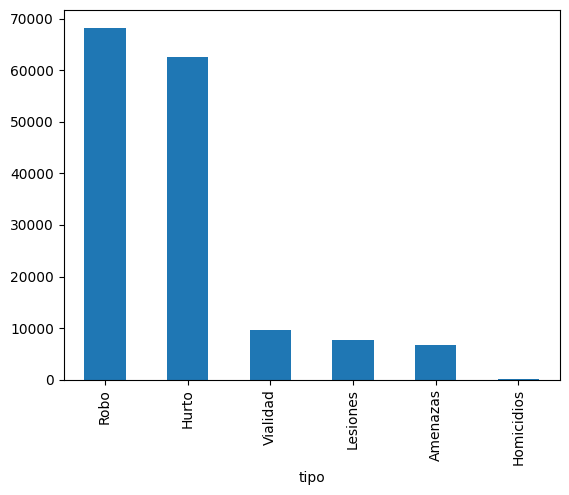

In [27]:
df_limpio["tipo"].value_counts().plot(kind="bar")

# La distribución de tipos de delitos #
- Muestra una fuerte concentración en las categorías Robo y Hurto, las cuales representan la mayor parte de los registros analizados. Por otro lado, delitos como Homicidios presentan una frecuencia considerablemente menor, evidenciando una distribución desigual entre las distintas categorías del DataSet.

# Distribución por día de la semana #

In [28]:
df_limpio["dia"].value_counts()

dia
VIERNES      23635
LUNES        22640
MIERCOLES    22451
SABADO       22434
JUEVES       22370
MARTES       21955
DOMINGO      19431
Name: count, dtype: int64

<Axes: xlabel='dia'>

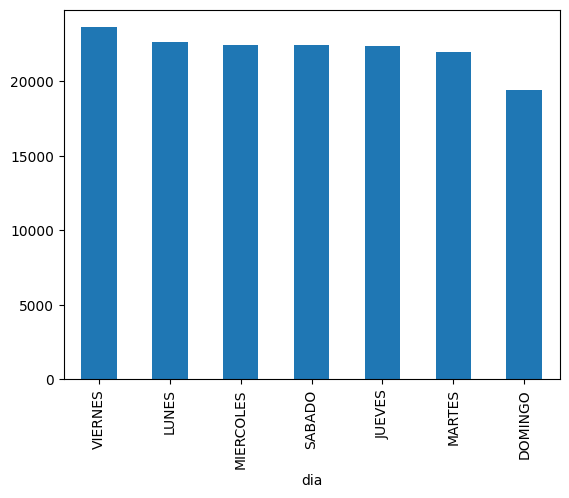

In [29]:
df_limpio["dia"].value_counts().plot(kind="bar")

# La distribución de delitos por día de la semana #
- Muestra una variación relativamente moderada entre los distintos días analizados, aunque se observan jornadas con una mayor concentración de registros. Este tipo de análisis permite identificar posibles patrones temporales en la ocurrencia de hechos delictivos.

# Distribución por franja horaria #

In [30]:
df_limpio["franja"].value_counts()

franja
18.0    8704
20.0    8448
17.0    8387
19.0    8127
8.0     8068
12.0    7993
21.0    7949
16.0    7754
7.0     7693
10.0    7409
15.0    7391
9.0     7374
22.0    7236
14.0    7176
13.0    6636
11.0    6491
23.0    6477
0.0     4943
6.0     4943
5.0     3555
1.0     3469
4.0     2923
2.0     2887
3.0     2842
Name: count, dtype: int64

<Axes: xlabel='franja', ylabel='Count'>

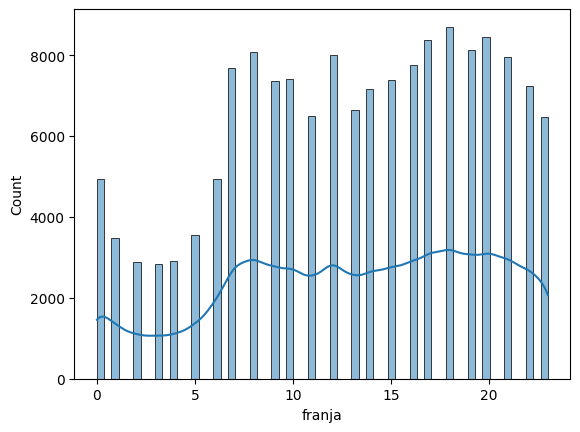

In [31]:
sns.histplot(df_limpio["franja"], kde=True)

# La distribución de la variable franja horaria #
- Permite observar en qué momentos del día se concentran los delitos registrados. El histograma junto con la curva KDE facilita la visualización de la frecuencia y densidad de ocurrencia de delitos según la hora del día, permitiendo identificar franjas horarias con mayor actividad delictiva.

# Distribución geográfica #

<Axes: xlabel='latitud', ylabel='Count'>

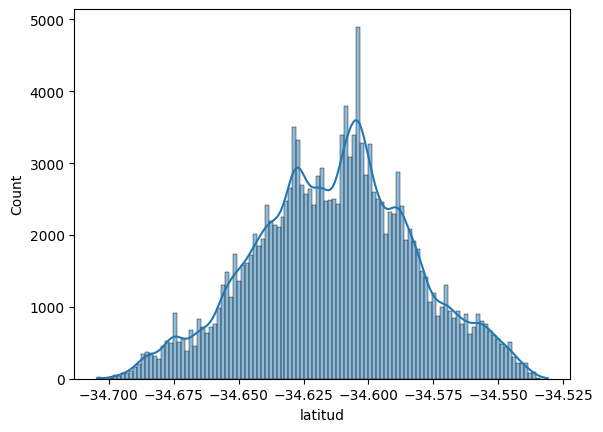

In [32]:
sns.histplot(df_limpio["latitud"], kde=True)

# El histograma de la variable latitud #
- Permite observar la distribución geográfica de los registros dentro de la Ciudad de Buenos Aires. La mayor concentración de valores se encuentra en rangos intermedios de latitud, evidenciando zonas con una mayor densidad de registros. La distribución obtenida resulta consistente luego del proceso de limpieza y depuración de coordenadas inválidas.

<Axes: xlabel='longitud', ylabel='Count'>

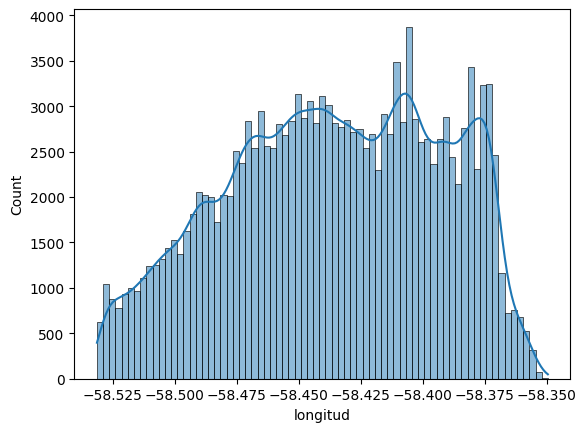

In [33]:
sns.histplot(df_limpio["longitud"], kde=True)

# El histograma de la variable longitud #
- Permite analizar la distribución espacial de los registros dentro de la Ciudad de Buenos Aires. La distribución evidencia concentraciones de registros en determinados rangos geográficos, reflejando zonas con mayor densidad de hechos registrados. Luego del proceso de depuración no se observan valores extremos significativos.

# Distribución por barrio #

In [34]:
df_limpio["barrio"].value_counts().head(10)

barrio
PALERMO         12794
BALVANERA        9967
FLORES           8509
CABALLITO        6863
RECOLETA         6690
ALMAGRO          6026
VILLA LUGANO     5861
SAN NICOLAS      5831
BARRACAS         5389
BELGRANO         5043
Name: count, dtype: int64

<Axes: xlabel='barrio'>

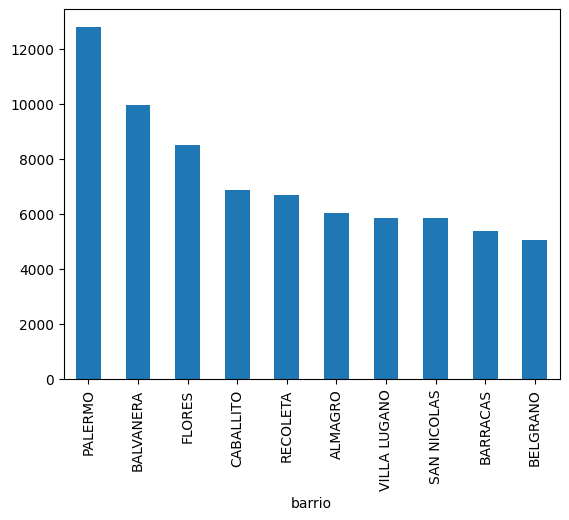

In [35]:
df_limpio["barrio"].value_counts().head(10).plot(kind="bar")
# sns.histplot(df_limpio["barrio"], kde=True)

# La distribución de delitos por barrio #
- Permite identificar las zonas con mayor concentración de registros dentro de la Ciudad de Buenos Aires. Para facilitar la visualización y el análisis comparativo, se presentan los 10 barrios con mayor cantidad de delitos registrados durante el período analizado.

# 4.3 Detección de Valores Atípicos #

<Axes: xlabel='latitud'>

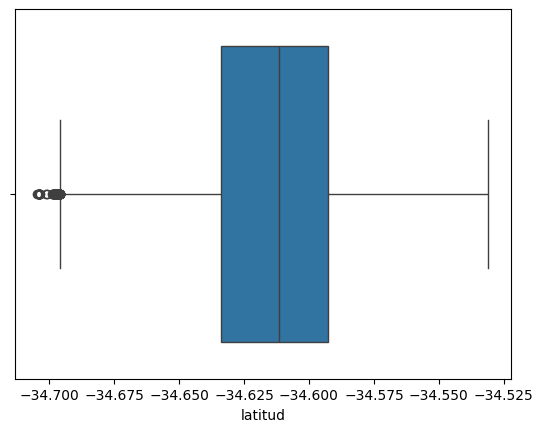

In [36]:
sns.boxplot(x=df_limpio["latitud"])

# El boxplot de la variable latitud #
- Permite visualizar la dispersión de los datos y detectar posibles valores atípicos. Luego del proceso de limpieza y depuración de coordenadas inconsistentes, la distribución presenta valores geográficos coherentes, aunque aún se observan algunos registros alejados de la concentración principal de datos.

<Axes: xlabel='longitud'>

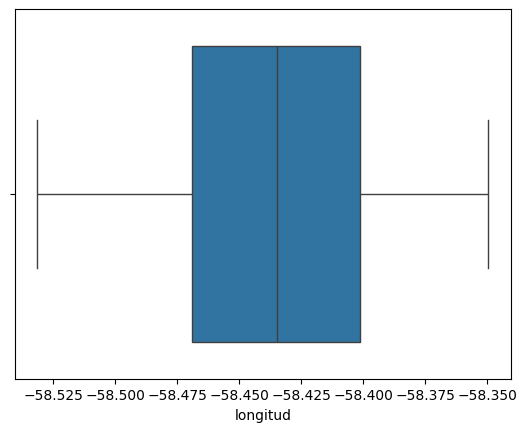

In [37]:
sns.boxplot(x=df_limpio["longitud"])

# El boxplot de la variable longitud # 
- Muestra una distribución relativamente estable y sin presencia significativa de valores atípicos luego del proceso de limpieza de datos. La mayor concentración de registros se encuentra dentro de un rango geográfico consistente con la Ciudad de Buenos Aires.

<Axes: xlabel='franja'>

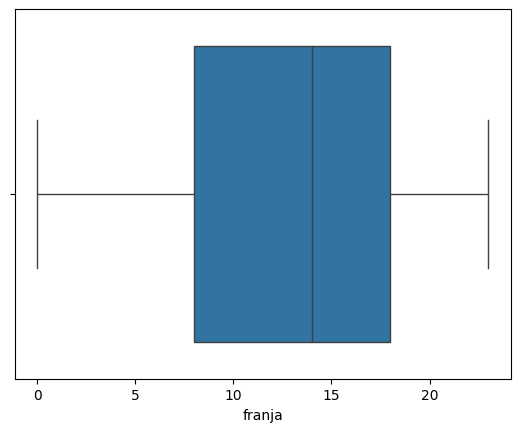

In [38]:
sns.boxplot(x=df_limpio["franja"])

# El boxplot de la variable franja horaria #
- Permite observar la distribución temporal de los registros del DataSet. La mayor concentración de delitos se ubica en horarios diurnos y vespertinos, sin evidenciar valores atípicos relevantes debido a que la variable posee límites naturales comprendidos entre 0 y 23 horas.

# 4.4 Relación entre Variables (Correlación) #

In [39]:
correlacion = df_limpio[["franja", "comuna", "latitud", "longitud"]].corr()

print(correlacion)

            franja    comuna   latitud  longitud
franja    1.000000 -0.008142  0.033043  0.015756
comuna   -0.008142  1.000000  0.355327 -0.658374
latitud   0.033043  0.355327  1.000000  0.065837
longitud  0.015756 -0.658374  0.065837  1.000000


<Axes: >

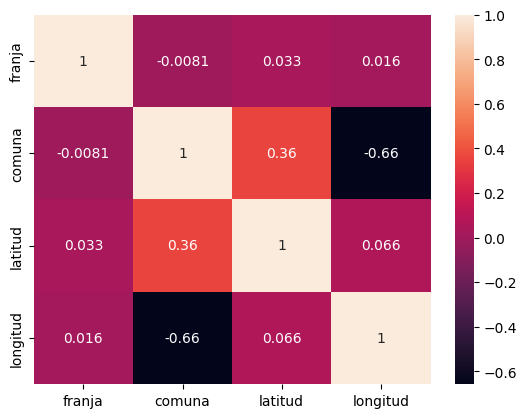

In [40]:
sns.heatmap(correlacion, annot=True)

In [41]:
correlacion_spearman = df_limpio[
    ["franja", "comuna", "latitud", "longitud"]
].corr(method="spearman")

print(correlacion_spearman)

            franja    comuna   latitud  longitud
franja    1.000000 -0.009820  0.035621  0.019221
comuna   -0.009820  1.000000  0.324771 -0.703517
latitud   0.035621  0.324771  1.000000  0.059418
longitud  0.019221 -0.703517  0.059418  1.000000


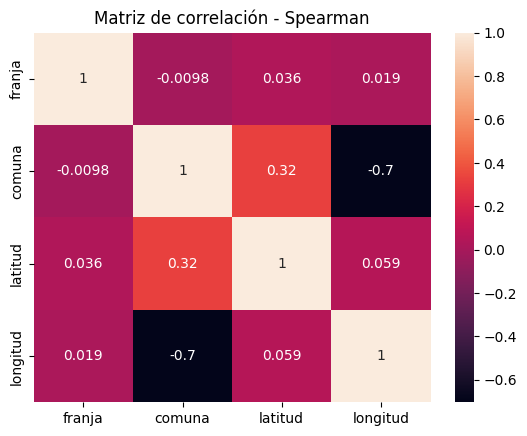

In [42]:
sns.heatmap(correlacion_spearman, annot=True)
plt.title("Matriz de correlación - Spearman")
plt.show()

# La Matriz de Correlación #
- Muestra que la mayoría de las variables numéricas presentan relaciones débiles entre sí. La correlación más significativa se observa entre las variables comuna y longitud, lo cual resulta consistente con la distribución geográfica de las comunas dentro de la Ciudad de Buenos Aires. En términos generales, no se identifican correlaciones lineales fuertes entre las variables analizadas.

<Axes: xlabel='longitud', ylabel='latitud'>

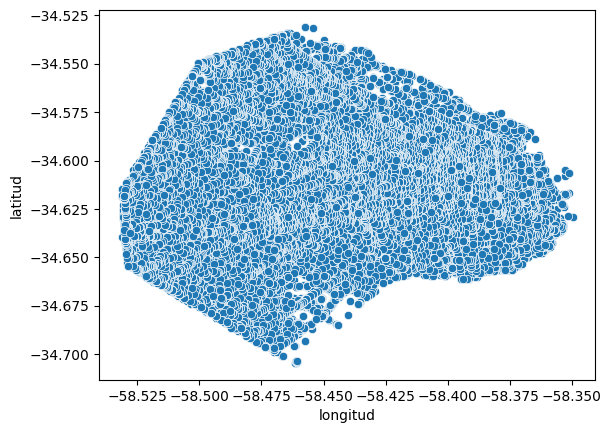

In [43]:
sns.scatterplot(
    x=df_limpio["longitud"],
    y=df_limpio["latitud"]
)

# El scatterplot entre longitud y latitud #
- Permite visualizar la distribución espacial de los registros dentro de la Ciudad de Buenos Aires. Luego del proceso de limpieza y depuración de coordenadas inconsistentes, se observa una concentración geográfica coherente y sin presencia significativa de valores extremos.

<Axes: xlabel='comuna', ylabel='longitud'>

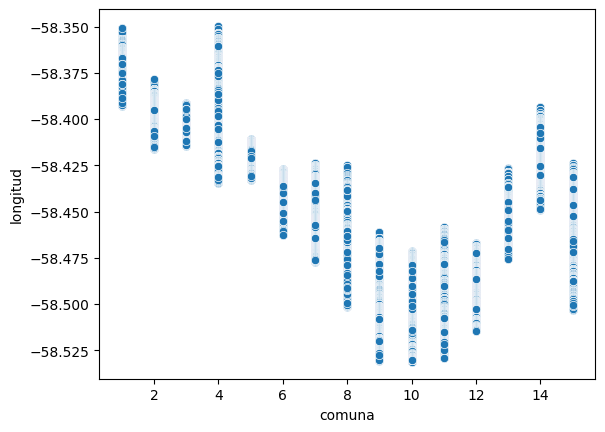

In [44]:
sns.scatterplot(
    x=df_limpio["comuna"],
    y=df_limpio["longitud"]
)

# El scatterplot entre comuna y longitud #
- Permite observar diferencias en la distribución geográfica de los registros dentro de la Ciudad de Buenos Aires. Se identifican concentraciones diferenciadas de valores de longitud según la comuna, lo cual resulta consistente con la correlación observada previamente entre ambas variables.

<Axes: xlabel='comuna', ylabel='latitud'>

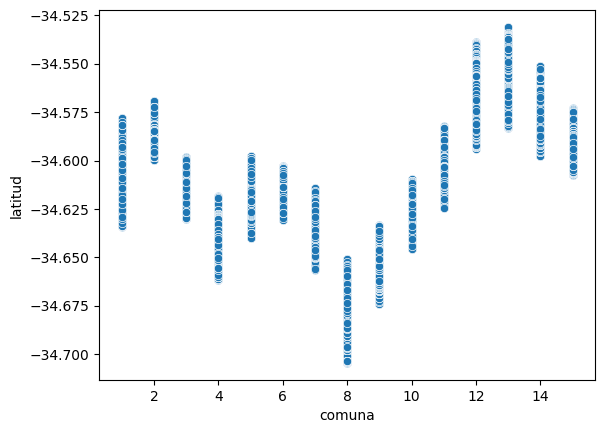

In [45]:
sns.scatterplot(
    x=df_limpio["comuna"],
    y=df_limpio["latitud"]
)

# El scatterplot entre comuna y latitud # 
- Permite observar diferencias geográficas entre las distintas comunas de la Ciudad de Buenos Aires. Se identifican agrupamientos de registros según determinados rangos de latitud, evidenciando la distribución territorial de las comunas dentro de la Ciudad.

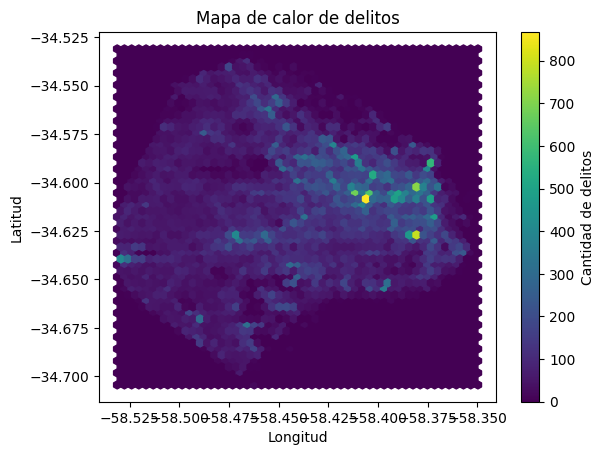

In [46]:
plt.hexbin(df_limpio["longitud"], df_limpio["latitud"], gridsize=50)
plt.colorbar(label="Cantidad de delitos")
plt.title("Mapa de calor de delitos")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

# Finalmente # 
- El mapa de calor geográfico permite visualizar las zonas con mayor concentración de delitos registrados dentro de la Ciudad de Buenos Aires. La visualización evidencia áreas con alta densidad de registros, principalmente en sectores urbanos de mayor circulación y actividad, permitiendo identificar patrones espaciales relevantes dentro del DataSet analizado.

# Consigna 5: Conclusiones

## Respuesta a hipótesis

### Hipótesis 1
# Se observó que algunos días de la semana presentan una mayor concentración de delitos registrados respecto de otros, evidenciando una distribución no uniforme de los hechos delictivos a lo largo de la semana.

### Hipótesis 2
# El análisis por barrio permitió identificar diferencias significativas en la cantidad de delitos registrados. Algunos barrios concentraron una mayor cantidad de hechos, evidenciando una distribución geográfica desigual dentro de la Ciudad de Buenos Aires.

### Hipótesis 3
# La distribución por franja horaria mostró una mayor frecuencia de delitos durante horarios diurnos y vespertinos, especialmente entre la mañana y la noche.

### Hipótesis 4
# Los delitos de tipo robo y hurto resultaron ser los más frecuentes dentro del DataSet analizado, representando la mayor proporción de registros respecto de otros tipos delictivos.

### Hipótesis 5
# Los delitos violentos, como homicidios y lesiones, representaron una proporción considerablemente menor respecto del total de delitos registrados, confirmando la hipótesis planteada inicialmente.

---

## Conclusión general

# A partir del análisis exploratorio realizado sobre el DataSet de delitos de la Ciudad de Buenos Aires correspondiente al año 2024, fue posible identificar patrones temporales y geográficos relevantes en la distribución de los hechos registrados.

# El proceso de limpieza permitió trabajar sobre un conjunto de datos consistente, corrigiendo valores nulos e inconsistencias detectadas durante las primeras etapas del análisis.

# Las visualizaciones y métricas obtenidas permitieron observar una fuerte predominancia de delitos de tipo robo y hurto, así como una mayor concentración de hechos en determinadas franjas horarias y zonas geográficas de la Ciudad.

# Asimismo, las variables geográficas mostraron una distribución coherente luego de la depuración de coordenadas inválidas, facilitando la interpretación espacial de los registros.

# En conclusión, el análisis exploratorio permitió comprender el comportamiento general del DataSet e identificar tendencias relevantes que podrían utilizarse como base para futuros análisis estadísticos o modelos predictivos.

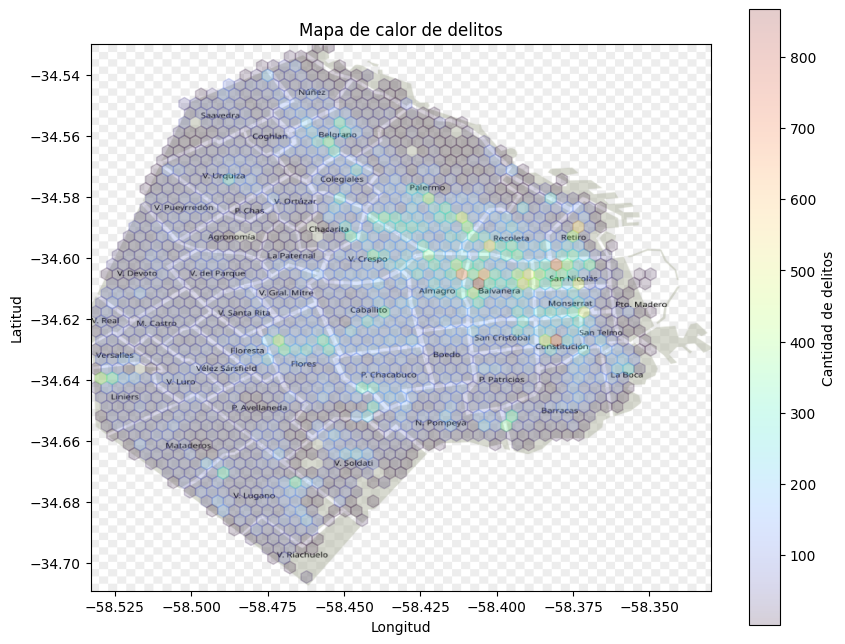

In [47]:
import matplotlib.pyplot as plt

# Cargar imagen del mapa
img = plt.imread("Mapa_CABA.png")

fig, ax = plt.subplots(figsize=(10,8))

# Mapa de fondo
ax.imshow(
    img,
    extent=[-58.533, -58.33, -34.709, -34.53],
    alpha=1,
    zorder=1
)

# Mapa encima
hb = ax.hexbin(
    df_limpio["longitud"],
    df_limpio["latitud"],
    gridsize=50,
    cmap="turbo",
    mincnt=1,
    alpha=0.2,
    zorder=2
)

# Barra de color
cb = plt.colorbar(hb)
cb.set_label("Cantidad de delitos")

ax.set_title("Mapa de calor de delitos")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.show()

## Visualización geográfica final ##

# El mapa de calor geográfico #
- Permite visualizar de manera integrada la concentración espacial de delitos registrados dentro de la Ciudad de Buenos Aires durante el año 2024. La superposición de los registros sobre el mapa de la Ciudad facilita la identificación de zonas con mayor densidad de hechos delictivos, evidenciando patrones espaciales consistentes con los resultados observados durante el análisis exploratorio. La visualización final resume gráficamente el comportamiento geográfico del DataSet luego del proceso de limpieza y depuración de coordenadas inconsistentes.